In [1]:
!pip install pandas fredapi numpy matplotlib seaborn plotly prophet scikit-learn statsmodels

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached cmdstanpy-1.3.0-py3-none-any.whl.metadata (4.2 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
  Using cached stanio-0.5.1-py3-none-any.whl.metadata (1.6 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 4.1 MB/s  0:00:024.1 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 3.9 MB/s  0:00:00m 5.0 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 4.2 MB/s  0:00:02 4.2 MB/s eta 0:00:01
Using cached cmdstanpy-1.3.0-py3-none-any.whl (99 kB)
Using cached stanio-0.5.1-py3-none-any.whl (8.1 kB)
Using cached patsy-1.0.2-py2.py3-none-any.whl (233 kB)
Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [prophet]5;237m━━━━ 8/9 [prophet]]

[notice] A new release of pip is availabl

# STEP 2: Import Libraries

In [2]:
import pandas as pd
import numpy as np
from fredapi import Fred
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ All libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")


✅ All libraries imported successfully!
Pandas version: 3.0.2


In [3]:
import pandas as pd
from fredapi import Fred

fred = Fred(api_key='54a6578aaa4821d9a2973db16ebb629f')

# Collect data
unemployment = fred.get_series('UNRATE')
cpi = fred.get_series('CPIAUCSL')
gdp = fred.get_series('GDP')
ffr = fred.get_series('FEDFUNDS')
hst = fred.get_series('HOUST')
dff = fred.get_series('DFF')
gdpnow = fred.get_series('GDPNOW')
consumer = fred.get_series('UMCSENT')
ind_pro = fred.get_series('INDPRO')
pym = fred.get_series('PAYEMS')

# Combine into one DataFrame
economic_data = pd.concat([
    unemployment.rename('unemployment'),
    cpi.rename('cpi'),
    gdp.rename('gdp'),
    ffr.rename('ffr'),
    hst.rename('hst'),
    dff.rename('dff'),
    gdpnow.rename('gdpnow'),
    consumer.rename('consumer'),
    ind_pro.rename('ind_pro'),
    pym.rename('pym')
], axis=1)

# 🔄 Resample everything to monthly frequency
economic_data_monthly = economic_data.resample('ME').mean()

# ============================================
# STEP 3: Set Up FRED API
# Get your free API key from: https://fred.stlouisfed.org/docs/api/api_key.html
# ============================================


In [4]:
# Replace 'YOUR_API_KEY_HERE' with your actual FRED API key
FRED_API_KEY = '7cdb1f27715579ab2c8dda4cd31d465d'

print("✅ FRED API initialized!")



✅ FRED API initialized!


# ============================================
# STEP 4: Test the Connection
# ============================================

In [5]:
# Test by fetching unemployment rate data
try:
    unemployment = fred.get_series('UNRATE', observation_start='2020-01-01')
    print(f"✅ Successfully fetched {len(unemployment)} data points for unemployment rate")
    print(f"\nLatest unemployment rate: {unemployment.iloc[-1]:.1f}%")
    print(f"Date: {unemployment.index[-1].strftime('%B %Y')}")
except Exception as e:
    print(f"❌ Error: {e}")
    print("Make sure you've replaced '54a6578aaa4821d9a2973db16ebb629f' with your actual API key")


✅ Successfully fetched 75 data points for unemployment rate

Latest unemployment rate: 4.3%
Date: March 2026


# ============================================
# STEP 5: Fetch Multiple Economic Indicators
# ============================================


In [6]:
def fetch_economic_data(start_date='2010-01-01'):
    """
    Fetch key economic indicators from FRED
    
    Parameters:
    -----------
    start_date : str
        Start date for data collection (format: 'YYYY-MM-DD')
    
    Returns:
    --------
    pd.DataFrame
        DataFrame with all economic indicators
    """
    
    indicators = {
        'UNRATE': 'Unemployment Rate',
        'CPIAUCSL': 'Consumer Price Index',
        'GDP': 'Gross Domestic Product',
        'FEDFUNDS': 'Federal Funds Rate',
        'HOUST': 'Housing Starts',
        'DFF': 'Federal Funds Effective Rate',
        'GDPNOW': 'GDPNow',
        'UMCSENT': 'Consumer Sentiment',
        'INDPRO': 'Industrial Production',
        'PAYEMS': 'Total Nonfarm Payrolls'
    }
    
    data_dict = {}
    
    print("Fetching economic indicators from FRED...")
    for code, name in indicators.items():
        try:
            series = fred.get_series(code, observation_start=start_date)
            data_dict[name] = series
            print(f"✅ {name}: {len(series)} observations")
        except Exception as e:
            print(f"❌ {name}: Error - {e}")


In [7]:
def fetch_economic_data(start_date='2010-01-01'):
    """
    Fetch key economic indicators from FRED
    
    Parameters:
    -----------
    start_date : str
        Start date for data collection (format: 'YYYY-MM-DD')
    
    Returns:
    --------
    pd.DataFrame
        DataFrame with all economic indicators
    """
    
    indicators = {
        'UNRATE': 'Unemployment Rate',
        'CPIAUCSL': 'Consumer Price Index',
        'GDP': 'Gross Domestic Product',
        'FEDFUNDS': 'Federal Funds Rate',
        'HOUST': 'Housing Starts',
        'DFF': 'Federal Funds Effective Rate',
        'GDPNOW': 'GDPNow',
        'UMCSENT': 'Consumer Sentiment',
        'INDPRO': 'Industrial Production',
        'PAYEMS': 'Total Nonfarm Payrolls'
    }
    
    data_dict = {}
    
    print("Fetching economic indicators from FRED...")
    for code, name in indicators.items():
        try:
            series = fred.get_series(code, observation_start=start_date)
            data_dict[name] = series
            print(f"✅ {name}: {len(series)} observations")
        except Exception as e:
            print(f"❌ {name}: Error - {e}")
    
    # Combine into DataFrame
    df = pd.DataFrame(data_dict)
    
    print(f"\n✅ Total data shape: {df.shape}")
    print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")
    
    return df

In [8]:
# Fetch the data
economic_data = fetch_economic_data()


Fetching economic indicators from FRED...
✅ Unemployment Rate: 195 observations
✅ Consumer Price Index: 195 observations
✅ Gross Domestic Product: 64 observations
✅ Federal Funds Rate: 195 observations
✅ Housing Starts: 195 observations
✅ Federal Funds Effective Rate: 5962 observations
✅ GDPNow: 59 observations
✅ Consumer Sentiment: 195 observations
✅ Industrial Production: 195 observations
✅ Total Nonfarm Payrolls: 195 observations

✅ Total data shape: (5962, 10)
Date range: 2010-01-01 to 2026-04-28


In [9]:
# Display first few rows
print("\n📊 Sample of Economic Data:")
economic_data.head()



📊 Sample of Economic Data:


,Unemployment Rate,Consumer Price Index,Gross Domestic Product,Federal Funds Rate,Housing Starts,Federal Funds Effective Rate,GDPNow,Consumer Sentiment,Industrial Production,Total Nonfarm Payrolls
2010-01-01,9.8,217.488,14764.61,0.11,614.0,0.05,NaN,74.4,89.3426,129802.0
2010-01-02,NaN,NaN,NaN,NaN,NaN,0.05,NaN,NaN,NaN,NaN
2010-01-03,NaN,NaN,NaN,NaN,NaN,0.05,NaN,NaN,NaN,NaN
2010-01-04,NaN,NaN,NaN,NaN,NaN,0.12,NaN,NaN,NaN,NaN
2010-01-05,NaN,NaN,NaN,NaN,NaN,0.12,NaN,NaN,NaN,NaN


# ============================================
# STEP 6: Quick Data Visualization
# ============================================


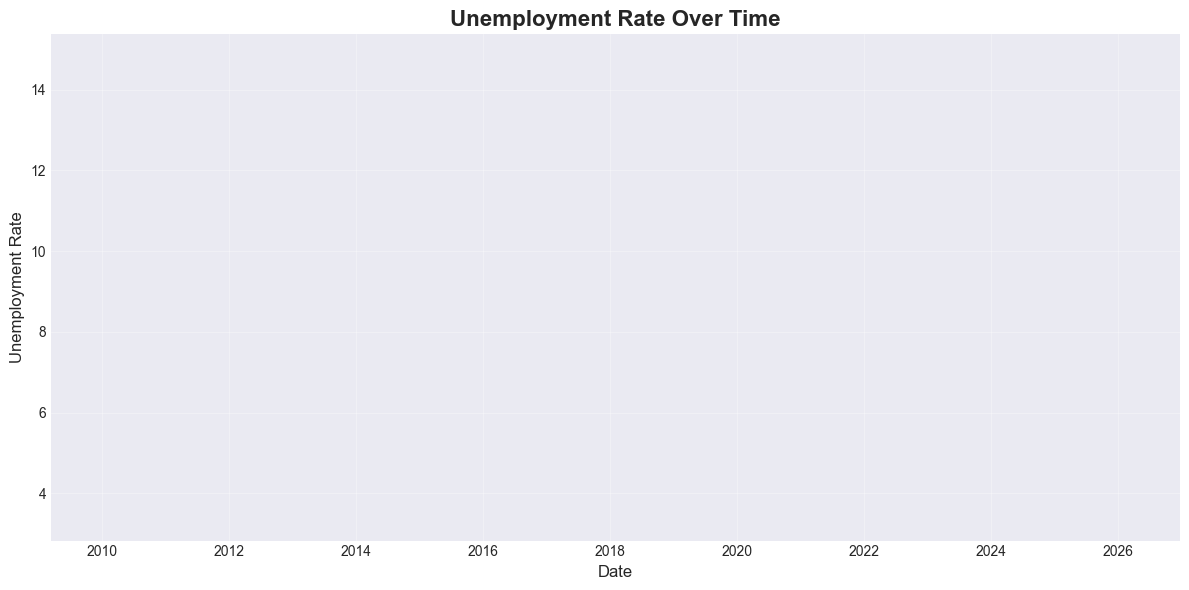

In [11]:
def plot_economic_indicator(df, column_name):
    """
    Create a simple time series plot
    """
    plt.figure(figsize=(12, 6))
    plt.plot(df.index, df[column_name], linewidth=2)
    plt.title(f'{column_name} Over Time', fontsize=16, fontweight='bold')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel(column_name, fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Example: Plot unemployment rate
if 'Unemployment Rate' in economic_data.columns:
    plot_economic_indicator(economic_data, 'Unemployment Rate')


# ============================================
# STEP 6b: Resample with monthly date index
# ============================================


In [12]:
# 🔄 Resample everything to monthly frequency
economic_data_monthly = economic_data.resample('ME').mean()

print(economic_data_monthly.tail())


            Unemployment Rate  Consumer Price Index  Gross Domestic Product  \
2025-12-31                4.4               326.031                     NaN   
2026-01-31                4.3               326.588                     NaN   
2026-02-28                4.4               327.460                     NaN   
2026-03-31                4.3               330.293                     NaN   
2026-04-30                NaN                   NaN                     NaN   

            Federal Funds Rate  Housing Starts  Federal Funds Effective Rate  \
2025-12-31                3.72          1373.0                      3.720645   
2026-01-31                3.64          1398.0                      3.640000   
2026-02-28                3.64          1356.0                      3.640000   
2026-03-31                3.64          1502.0                      3.640000   
2026-04-30                 NaN             NaN                      3.640000   

            GDPNow  Consumer Sentiment  Indu

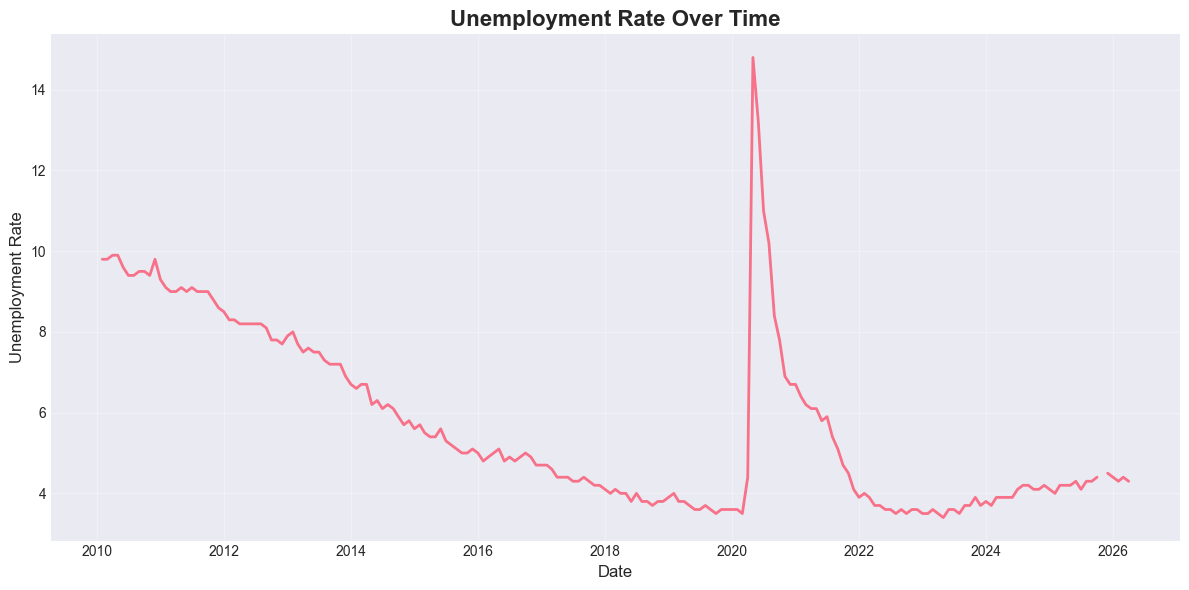

In [13]:
def plot_economic_indicator(df, column_name):
    """
    Create a simple time series plot
    """
    plt.figure(figsize=(12, 6))
    plt.plot(df.index, df[column_name], linewidth=2)
    plt.title(f'{column_name} Over Time', fontsize=16, fontweight='bold')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel(column_name, fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Example: Plot unemployment rate
if 'Unemployment Rate' in economic_data_monthly.columns:
    plot_economic_indicator(economic_data_monthly, 'Unemployment Rate')


In [14]:
# Display first few rows
print("\n📊 Sample of Economic Data:")
economic_data_monthly.tail()



📊 Sample of Economic Data:


,Unemployment Rate,Consumer Price Index,Gross Domestic Product,Federal Funds Rate,Housing Starts,Federal Funds Effective Rate,GDPNow,Consumer Sentiment,Industrial Production,Total Nonfarm Payrolls
2025-12-31,4.4,326.031,NaN,3.72,1373.0,3.720645,NaN,52.9,101.6113,158432.0
2026-01-31,4.3,326.588,NaN,3.64,1398.0,3.640000,1.2392,56.4,101.5954,158592.0
2026-02-28,4.4,327.460,NaN,3.64,1356.0,3.640000,NaN,56.6,102.3440,158459.0
2026-03-31,4.3,330.293,NaN,3.64,1502.0,3.640000,NaN,53.3,101.7898,158637.0
2026-04-30,NaN,NaN,NaN,NaN,NaN,3.640000,NaN,NaN,NaN,NaN


# ============================================
# STEP 7a: Data Summary Statistics a
# ============================================


In [15]:
print("\n📈 Summary Statistics:")
print(economic_data.describe())

print("\n🔍 Missing Values:")
print(economic_data.isnull().sum())

print("\n📅 Data Frequency:")
print(f"Total observations: {len(economic_data)}")
print(f"Date range: {(economic_data.index.max() - economic_data.index.min()).days} days")



📈 Summary Statistics:
       Unemployment Rate  Consumer Price Index  Gross Domestic Product  \
count         194.000000            194.000000               64.000000   
mean            5.687629            259.122629            21207.949719   
std             2.191021             32.768893             4884.890514   
min             3.400000            217.199000            14764.610000   
25%             3.925000            234.882250            17196.308250   
50%             4.800000            249.194000            19997.689500   
75%             7.275000            284.010750            24922.786750   
max            14.800000            330.293000            31422.526000   

       Federal Funds Rate  Housing Starts  Federal Funds Effective Rate  \
count          195.000000      195.000000                   5962.000000   
mean             1.449949     1168.451282                      1.460273   
std              1.820746      314.429546                      1.819949   
min       

# ============================================
# STEP 7b: Data Summary Statistics b
# ============================================


In [16]:
print("\n📈 Summary Statistics:")
print(economic_data_monthly.describe())

print("\n🔍 Missing Values:")
print(economic_data_monthly.isnull().sum())

print("\n📅 Data Frequency:")
print(f"Total observations: {len(economic_data_monthly)}")
print(f"Date range: {(economic_data_monthly.index.max() - economic_data_monthly.index.min()).days} days")



📈 Summary Statistics:
       Unemployment Rate  Consumer Price Index  Gross Domestic Product  \
count         194.000000            194.000000               64.000000   
mean            5.687629            259.122629            21207.949719   
std             2.191021             32.768893             4884.890514   
min             3.400000            217.199000            14764.610000   
25%             3.925000            234.882250            17196.308250   
50%             4.800000            249.194000            19997.689500   
75%             7.275000            284.010750            24922.786750   
max            14.800000            330.293000            31422.526000   

       Federal Funds Rate  Housing Starts  Federal Funds Effective Rate  \
count          195.000000      195.000000                    196.000000   
mean             1.449949     1168.451282                      1.460874   
std              1.820746      314.429546                      1.822796   
min       

# ============================================
# BONUS: Save Data to CSV
# ============================================


In [17]:
# Save to CSV for future use
economic_data.to_csv('economic_indicators.csv')
print("\n💾 Data saved to 'economic_indicators.csv'")



💾 Data saved to 'economic_indicators.csv'


In [18]:
# Save to CSV for future use
economic_data_monthly.to_csv('economic_indicators_timeseries.csv')
print("\n💾 Data saved to 'economic_indicators_timeseries.csv'")



💾 Data saved to 'economic_indicators_timeseries.csv'


In [19]:
print("\n" + "="*50)
print("🎉 SETUP COMPLETE!")
print("="*50)
print("\nNext steps:")
print("1. Explore the data further")
print("2. Create visualizations")
print("3. Build forecasting models")
print("4. Check out the project guide for detailed instructions!")


🎉 SETUP COMPLETE!

Next steps:
1. Explore the data further
2. Create visualizations
3. Build forecasting models
4. Check out the project guide for detailed instructions!
